# Extra Practice

This is meant to help you practise the same core skills you developed in the previous exercises. Completing these exercises are **optional** and only meant to provide a little extra practice if you want. 


### Set up Python Libraries

As usual you will need to run this code block to import the relevant Python libraries

In [1]:
# Set-up Python libraries - you need to run this but you don't need to change it
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')
import statsmodels.api as sm
import statsmodels.formula.api as smf

## 1. Does Lunch Improve Decision Making

A behavioural scientist investigates whether being fed improves decision-making.

Participants complete a decision-making task twice on the same day:

- **Before lunch**
- **After lunch**

Scores reflect task performance (higher scores indicate better decisions).

a) Comment on the design of the study

< Comment here>

c) Load the data into a Pandas dataframe

In [2]:
decision = pd.read_csv("https://raw.githubusercontent.com/SageBoettcher/StatsCourseBook_2026/main/data/decision_making_lunch_study.csv")

decision

,ParticipantID,LunchOption,BeforeLunchScore,AfterLunchScore
0,1,Veg,57.1,59.200000
1,2,Veg,58.6,60.100000
2,3,Meat,63.4,67.100000
3,4,Meat,70.9,73.000000
4,5,Meat,67.0,71.000000
5,6,Veg,64.5,68.300000
6,7,Veg,57.1,62.900000
7,8,Veg,60.0,66.900000
8,9,Meat,63.8,67.300000
9,10,Veg,69.2,70.500000


d) Plot the raw data for before and after lunch and plot the distribtuino of the differences. Comment on both. 

Note you may need to add a Diff column to the dataset

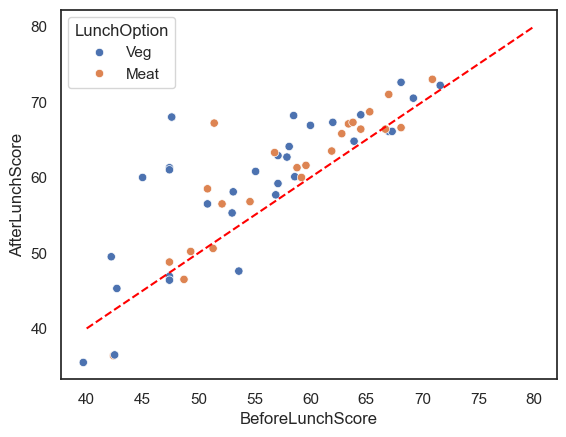

In [3]:
sns.scatterplot(data=decision, x='BeforeLunchScore', y='AfterLunchScore', hue='LunchOption')
plt.plot([40,80],[40,80], color='red', linestyle='--')

In [4]:
decision['Difference'] = decision.AfterLunchScore - decision.BeforeLunchScore

<Axes: xlabel='Difference', ylabel='Density'>

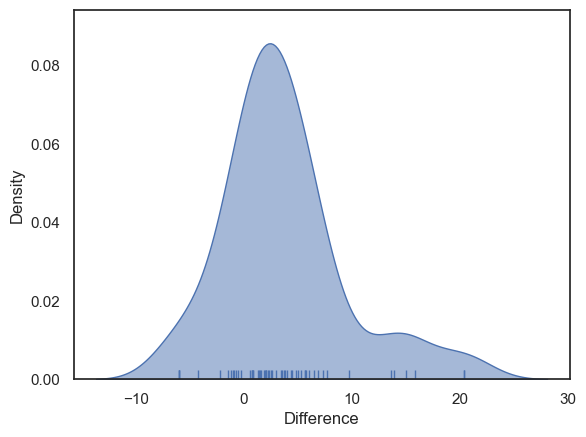

In [5]:
sns.kdeplot(data=decision, x='Difference', fill=True, alpha=0.5)
sns.rugplot(data=decision, x='Difference')

e) Conduct a suitable rank-based non-parametric test to assess whether lunch improves decision-making scores. For this you should:

* State your hypotheses
* State relevant descriptive statistics
* Carry out the test using the built in function from `scipy.stats` with appropriate option choices
* State your conclusions

In [6]:
decision.describe()

,ParticipantID,BeforeLunchScore,AfterLunchScore,Difference
count,55.00000,55.000000,55.000000,55.000000
mean,28.00000,56.310909,59.998424,3.687515
std,16.02082,8.474464,9.359876,5.692004
min,1.00000,39.700000,35.500000,-6.000000
25%,14.50000,49.000000,56.500000,0.800000
50%,28.00000,57.100000,61.600000,2.500000
75%,41.50000,63.600000,67.000000,5.700000
max,55.00000,71.600000,73.000000,20.400000


In [7]:
stats.wilcoxon(decision.BeforeLunchScore, decision.AfterLunchScore, alternative='less')

WilcoxonResult(statistic=np.float64(234.0), pvalue=np.float64(3.5438155824230483e-06))

f) Conduct a suitable permutation test of VitalVit's claim

* State your hypotheses
* State relevant descriptive statistics
* Carry out the test using the built in function from `scipy.stats` with appropriate option choices
* State your conclusions

In [8]:
def mDiff(x, y):
    return np.mean(x-y)

results = stats.permutation_test((decision.BeforeLunchScore, decision.AfterLunchScore), mDiff, permutation_type='samples', alternative='less', n_resamples=10000)

print(results)

PermutationTestResult(statistic=np.float64(-3.6875146133206305), pvalue=np.float64(9.999000099990002e-05), null_distribution=array([ 0.01140939, -0.77793993,  1.38959121, ..., -0.92677242,
        0.83612175,  0.67612175], shape=(10000,)))


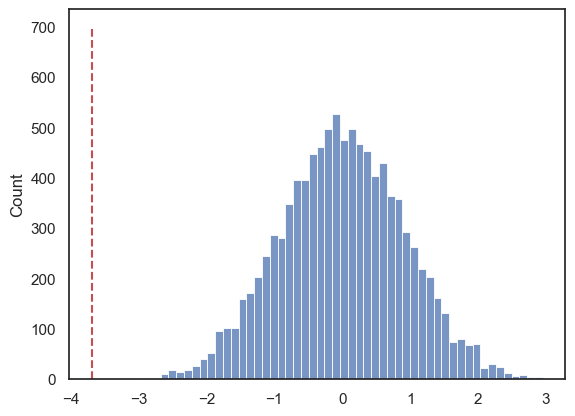

In [9]:
sns.histplot(results.null_distribution)
plt.plot([results.statistic,results.statistic],[0,700], 'r--')
plt.show()

## 2. Correlation
The researcher was also interested in the **reliability** of the decision-making task. In particular, they wanted to know whether individuals who performed well before lunch also tended to perform well after lunch.

This can be assessed by examining the **correlation of decision-making scores within individuals** across the two testing sessions. A strong positive correlation would suggest that the task reliably captures stable individual differences in decision-making ability, even if overall performance changes after lunch.


a) Plot the data and comment on what an appropriate test would be then carry out this test


<Axes: xlabel='BeforeLunchScore', ylabel='AfterLunchScore'>

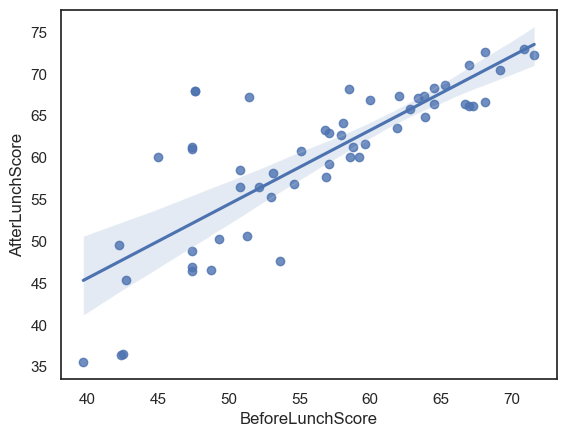

In [10]:
sns.regplot(data=decision, x='BeforeLunchScore', y='AfterLunchScore')

In [11]:
stats.spearmanr(decision.BeforeLunchScore, decision.AfterLunchScore)


SignificanceResult(statistic=np.float64(0.7845618472412718), pvalue=np.float64(1.3707523636737371e-12))

Now carry out the permuation version

In [12]:
def correlate(x, y):
    tmp = np.corrcoef(x,y)
    c = tmp[0][1] 
    return c

results = stats.permutation_test((decision.BeforeLunchScore, decision.AfterLunchScore), correlate, 
                                  permutation_type='pairings', alternative='greater', n_resamples=10000)
print(results)

PermutationTestResult(statistic=np.float64(0.8007124172606844), pvalue=np.float64(9.999000099990002e-05), null_distribution=array([ 0.0445474 , -0.02762292, -0.16980013, ...,  0.01142445,
        0.15812014,  0.05295906], shape=(10000,)))


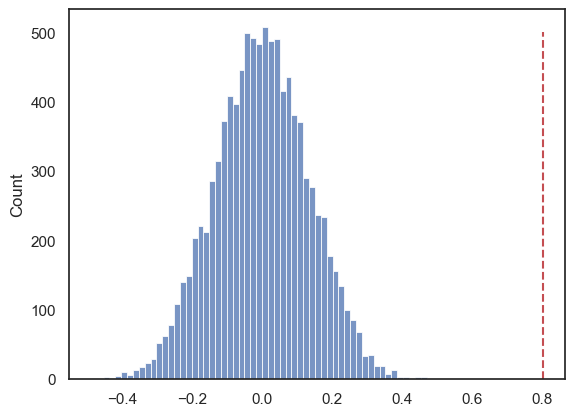

In [13]:
sns.histplot(results.null_distribution)
plt.plot([results.statistic,results.statistic],[0,500], 'r--')
plt.show()

### 3. Does Meat vs. Veg Lunch Matter

The researcher also asked participants whether they went for the meat or the veg option. They are interested in whether this choice will affect their `AfterLunchScore`. 

a) Plot the differences between the groups

<Axes: xlabel='AfterLunchScore', ylabel='Density'>

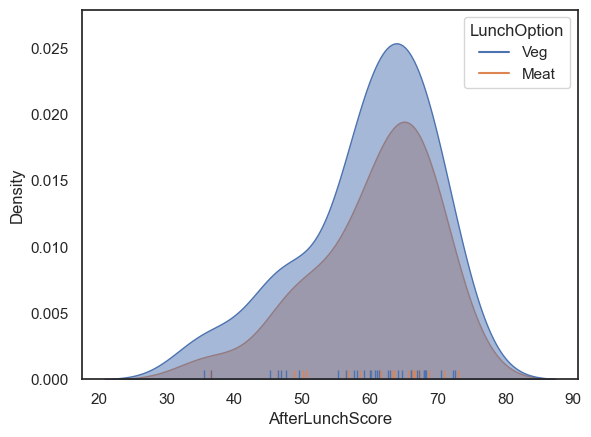

In [14]:
sns.kdeplot(data=decision, x = 'AfterLunchScore', hue = 'LunchOption', fill=True, alpha=0.5)
sns.rugplot(data=decision, x = 'AfterLunchScore', hue = 'LunchOption') 

b) Conduct an appropriate rank-based non-parametric test of the decision making scores

* State your hypotheses
* State relevant descriptive statistics
* Carry out the test using the built in function from `scipy.stats` with appropriate option choices
* State your conclusions

In [15]:
decision.groupby('LunchOption').AfterLunchScore.describe()

,count,mean,std,min,25%,50%,75%,max
LunchOption,,,,,,,,
Meat,23.0,60.586957,8.978778,36.4,56.65,63.300000,66.85,73.0
Veg,32.0,59.575416,9.744302,35.5,56.20,61.156652,67.00,72.6


In [16]:
stats.mannwhitneyu(decision.query('LunchOption=="Veg"').AfterLunchScore,
                   decision.query('LunchOption=="Meat"').AfterLunchScore,
                   alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(344.5), pvalue=np.float64(0.6946935622833554))

c) Conduct a permutation test of the same claim

* State your hypotheses
* State relevant descriptive statistics
* Carry out the test using the built in function from `scipy.stats` with appropriate option choices
* State your conclusions

In [17]:
def dMeans(x, y):
    return np.mean(x)-np.mean(y)

results = stats.permutation_test((decision.query('LunchOption=="Veg"').AfterLunchScore, decision.query('LunchOption=="Meat"').AfterLunchScore), dMeans, 
                                  permutation_type='independent', alternative='two-sided', n_resamples=10000)
print(results)

PermutationTestResult(statistic=np.float64(-1.0115407800943004), pvalue=np.float64(0.6941305869413059), null_distribution=array([ 3.90557879,  1.77582335, -0.65284513, ..., -2.69292665,
       -0.54769451,  4.84768593], shape=(10000,)))


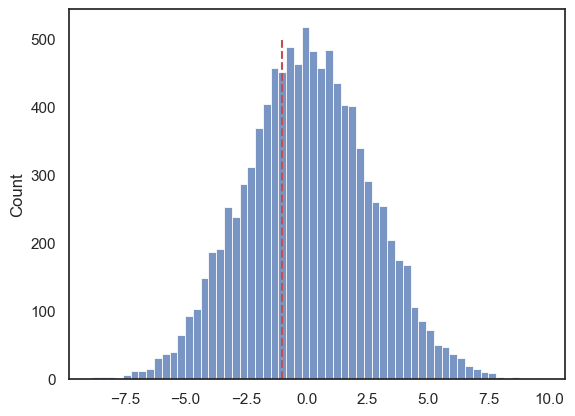

In [18]:
sns.histplot(results.null_distribution)
plt.plot([results.statistic,results.statistic],[0,500], 'r--')
plt.show()